# Exercise 2 — Simulating your own targets

*Covers notebooks 01–02. Difficulty: ★★☆☆☆*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

### 2.1 — A kilonova

A kilonova at $z=0.05$, 1.4 days after the merger, seen at 30° from the pole.
What exposure time gives an average SNR of 10 per resolution element between 6000 and 9000 Å
(observer frame)? Plot the observed spectrum.

226 s {'nmd': (20, 4, 0), 'nramps': 1}


[Text(0.5, 0, 'wavelength [Å]'), Text(0, 0.5, 'flux [erg/s/cm²/Å]')]

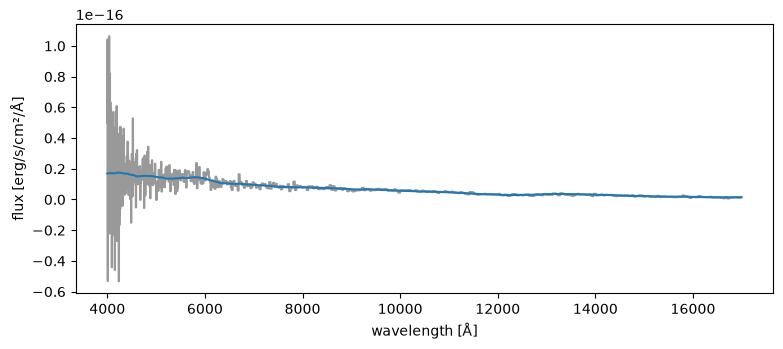

In [2]:
kilonova = slicersim.LazuliKilonova(redshift=0.05, phase=1.4, theta=30)
_ = kilonova.setup_to_snr(10, lbda_range=[6000, 9000], frame="obs")
print(f"{kilonova.get_exposure_time():.0f} s", kilonova.get_readout_config())

lbda, flux, variance = kilonova.get_spectrum(unit="flambda")
_, flux_true, _ = kilonova.get_spectrum(unit="flambda", incl_error=False)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lbda, flux, color="0.6", ds="steps-mid")
ax.plot(lbda, flux_true)
ax.set(xlabel="wavelength [Å]", ylabel="flux [erg/s/cm²/Å]")

### 2.2 — Viewing angle

With the same exposure, what SNR do you get if the kilonova is seen edge-on (`theta=90`)?
Plot both spectra (noise-free) on the same figure.

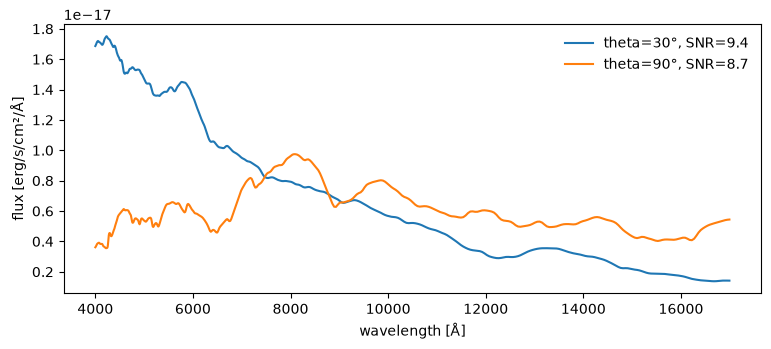

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for theta in [30, 90]:
    kilonova.change_properties(theta=theta)
    lbda, flux, _ = kilonova.get_spectrum(unit="flambda", incl_error=False)
    snr = kilonova.get_band_snr([6000, 9000], frame="obs")
    ax.plot(lbda, flux, label=f"theta={theta}°, SNR={snr:.1f}")
ax.set(xlabel="wavelength [Å]", ylabel="flux [erg/s/cm²/Å]")
ax.legend(frameon=False)

### 2.3 — Build a type II supernova

Build a toy type II SN spectrum at $z=0.4$: a blackbody of 8000 K plus a broad Hα emission line
(rest-frame 6563 Å, Gaussian with σ=60 Å, equivalent width 300 Å). Create the corresponding
`LazuliTarget` with a magnitude of 23.5 in `sdssr`.

*Hint: the amplitude does not matter since you set the magnitude. For the blackbody, you can use*
`slicersim.scene.sources.blackbody.get_blackbody_flux(lbda, temperature, mag)`.

In [4]:
from slicersim.scene.sources.blackbody import get_blackbody_flux

def typeii_spectrum(lbda, redshift=0.4, temperature=8000, ew=300, sigma=60):
    lbda_rest = lbda / (1 + redshift)
    continuum = get_blackbody_flux(lbda_rest, temperature=temperature, mag=20)
    line = np.exp(-0.5 * ((lbda_rest - 6563) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)
    return continuum * (1 + ew * line)

lbda_in = np.arange(3000, 20_000, 1.0)
flux_in = typeii_spectrum(lbda_in)
snii = slicersim.LazuliTarget(lbda_in, flux_in, mag=23.5, band="sdssr")

### 2.4 — Detect the line

Set the instrument to reach SNR=10 on the Hα line (observer-frame range covering ±1σ of the line)
and plot the observed spectrum. What is the exposure time?

0.11 h {'nmd': (18, 8, 0), 'nramps': 1}


[Text(0.5, 0, 'wavelength [Å]'), Text(0, 0.5, 'flux [erg/s/cm²/Å]')]

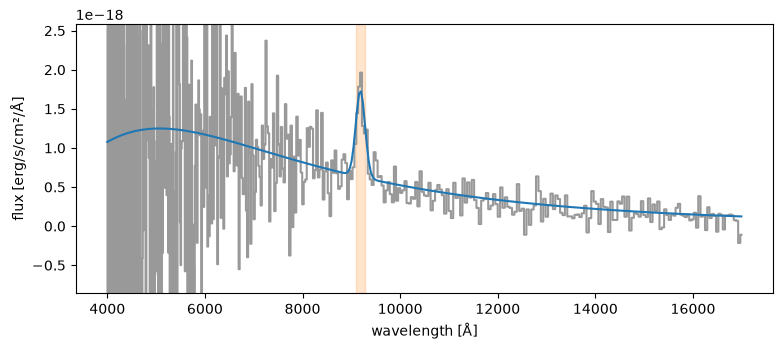

In [5]:
halpha_obs = 6563 * 1.4
halpha_range = [halpha_obs - 60 * 1.4, halpha_obs + 60 * 1.4]
_ = snii.setup_to_snr(10, lbda_range=halpha_range, frame="obs")
print(f"{snii.get_exposure_time()/3600:.2f} h", snii.get_readout_config())

lbda, flux, variance = snii.get_spectrum(unit="flambda")
_, flux_true, _ = snii.get_spectrum(unit="flambda", incl_error=False)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lbda, flux, color="0.6", ds="steps-mid")
ax.plot(lbda, flux_true)
ax.axvspan(*halpha_range, color="C1", alpha=0.2)
ax.set_ylim(-0.5 * flux_true.max(), 1.5 * flux_true.max())
ax.set(xlabel="wavelength [Å]", ylabel="flux [erg/s/cm²/Å]")

### 2.5 — Is the line significant?

Build a `LazuliBlackBody` with the same temperature (8000 K, redshifted to $z=0.4$ i.e.
$T/(1+z)$ in the observer frame), rescale it to match the continuum of your SN II, and set it to
the same detector configuration. Plot (SN II − blackbody) / error to show the significance of
the line per wavelength bin.

*Hints: `change_detector(**snii.get_readout_config())`; a redshifted blackbody is a blackbody of
temperature $T/(1+z)$.*

[Text(0.5, 0, 'wavelength [Å]'),
 Text(0, 0.5, '(SN II - continuum) / σ'),
 (6000.0, 16000.0)]

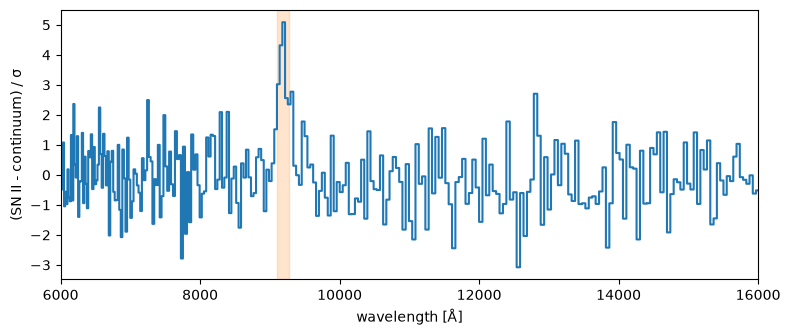

In [6]:
continuum = slicersim.LazuliBlackBody(temperature=8000 / 1.4, mag=23.5, band="sdssr")
continuum.change_detector(**snii.get_readout_config())

_, flux_cont, _ = continuum.get_spectrum(unit="flambda", incl_error=False)
# rescale the continuum to the SN II flux away from the line
off_line = (lbda > 6000) & (lbda < 8000)
flux_cont *= np.median(flux_true[off_line] / flux_cont[off_line])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lbda, (flux - flux_cont) / np.sqrt(variance), ds="steps-mid")
ax.axvspan(*halpha_range, color="C1", alpha=0.2)
ax.set(xlabel="wavelength [Å]", ylabel="(SN II - continuum) / σ", xlim=(6000, 16000))